In [1]:
pip install pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [5]:
data = pd.read_csv("car.csv")


In [6]:
# Display first 5 rows
print("First 5 Rows of Dataset:\n")
print(data.head())

First 5 Rows of Dataset:

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio hors

In [7]:
# Convert text columns into numbers using Label Encoding
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

In [8]:
# Input Features (X)
X = data.drop('price', axis=1)

In [9]:
# Target Variable (y)
y = data['price']

In [10]:
# Split dataset into Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:

# Create Decision Tree Regressor Model
model = DecisionTreeRegressor(random_state=42)


In [12]:
# Train the model
model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [13]:
# Predict test data
y_pred = model.predict(X_test)


In [14]:
# Calculate Accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Model Evaluation
Mean Absolute Error: 2090.699195121951
R2 Score: 0.8792534802425853


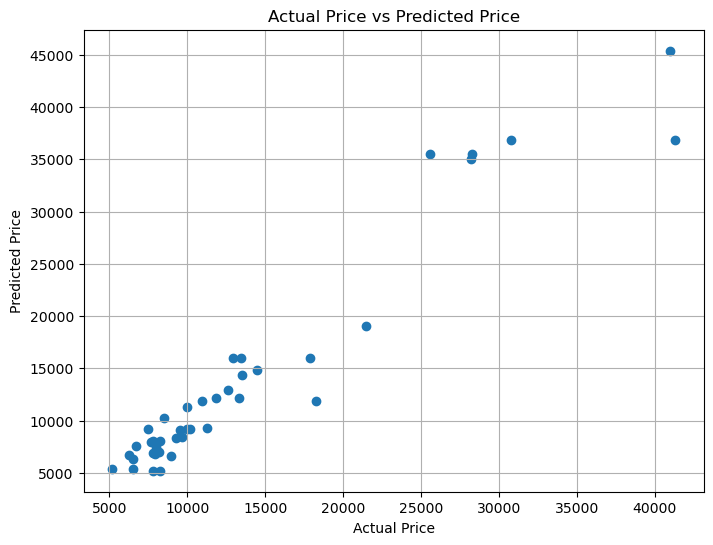

In [15]:
# Graph 1: Actual Price vs Predicted Price
# -------------------------------

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.grid(True)
plt.show()

In [16]:
# Graph 2: Feature Importance
# -------------------------------

importance = model.feature_importances_
features = X.columns

# Create dataframe
feature_data = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

In [18]:
# Sort values
feature_data = feature_data.sort_values(by='Importance', ascending=False)

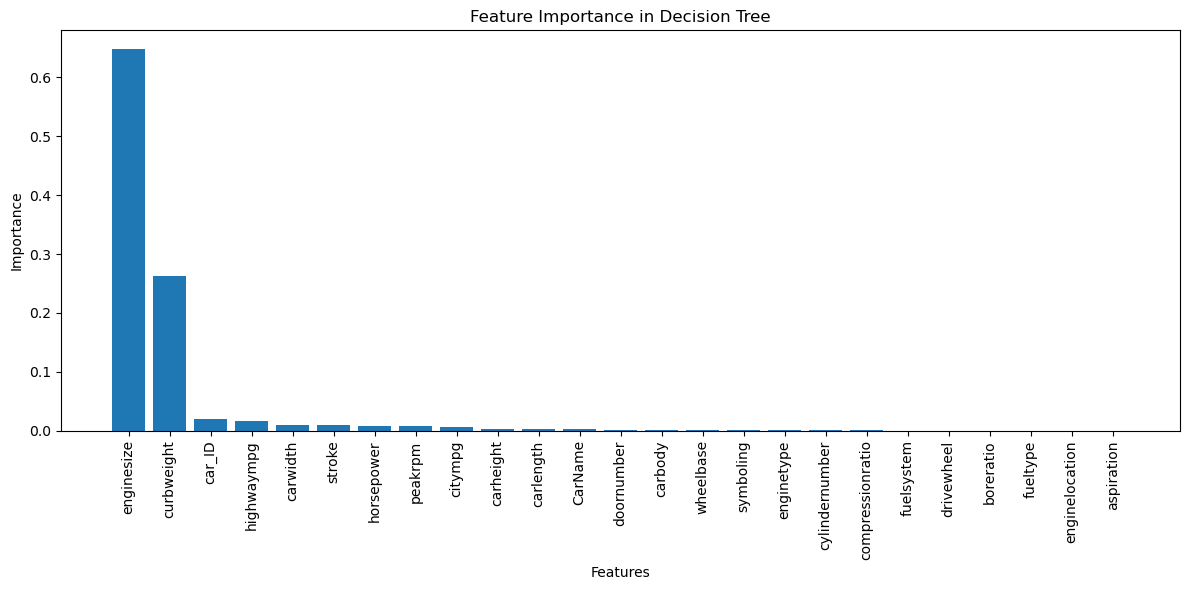

In [19]:
# Plot graph
plt.figure(figsize=(12,6))
plt.bar(feature_data['Feature'], feature_data['Importance'])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Decision Tree")
plt.tight_layout()
plt.show()


In [20]:
# Sample Prediction
# -------------------------------

sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("\nSample Predicted Car Price:", prediction[0])



Sample Predicted Car Price: 36880.0
